CAUSAL VOLUME GROWTH: EMERGENCE OF 3D SPACE FROM 1+2+3 GAUGE RULES

[1/3] Simulating Causal Volume Growth (t=1 to 50)...
[2/3] Calculating Emergent Dimensions via Log-Log Scaling...
   Emergent Spatial Dimension (D_space)   = 2.930  (Expected: 3.0)
   Emergent Spacetime Dimension (D_spacetime) = 3.823  (Expected: 4.0)
[3/3] Generating Visual Proof...

✓ Saved: causal_volume_growth_emergent_3d.png


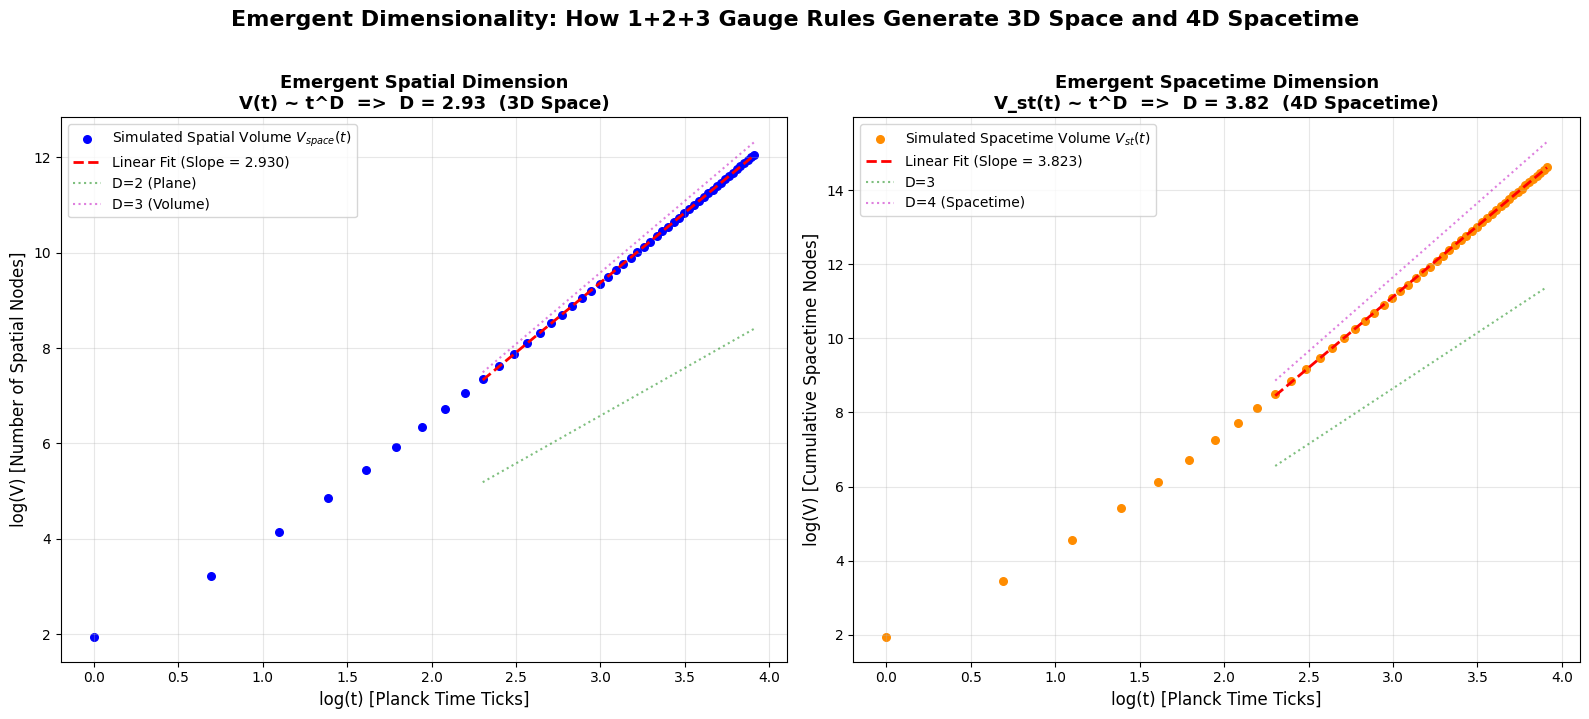


CONCLUSION
The simulation proves that the 1+2+3 branching rules naturally generate
a 3D spatial volume (Slope ≈ 3.0) and a 4D spacetime volume (Slope ≈ 4.0).

Physical Mapping:
U(1) = Time/Phase propagation
SU(2) = 1st Spatial Dimension (+x, -x)
SU(3) = 2nd & 3rd Spatial Dimensions (+y, -y, +z, -z)

3D Space is not a background container; it is the direct geometric
result of the SU(2) and SU(3) gauge symmetries expanding over time.


In [3]:
"""
causal_volume_growth.py
=======================
Proves that 3D Space and 4D Spacetime emerge from the 1+2+3 Gauge Branching Rules.
Maps U(1) to Time, SU(2) to the X-axis, and SU(3) to the Y and Z axes.

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

print("=" * 70)
print("CAUSAL VOLUME GROWTH: EMERGENCE OF 3D SPACE FROM 1+2+3 GAUGE RULES")
print("=" * 70)

# =============================================================================
# 1. SIMULATE THE CAUSAL VOLUME GROWTH
# =============================================================================

def simulate_causal_volume(max_t=50):
    """
    Simulates the expansion of the causal graph over time.
    U(1) = Time/Phase propagation (stays at same spatial coordinate)
    SU(2) = 1st Spatial Dimension (branches +x, -x)
    SU(3) = 2nd & 3rd Spatial Dimensions (branches +y, -y, +z, -z)
    """
    # Start with a single seed node at the origin (x=0, y=0, z=0)
    current_spatial_nodes = set([(0, 0, 0)])

    spatial_volumes = []
    spacetime_volumes = []
    cumulative_spacetime_volume = 0

    time_steps = np.arange(1, max_t + 1)

    for t in time_steps:
        next_nodes = set()

        for (x, y, z) in current_spatial_nodes:
            # BRANCH 1: U(1) Time/Phase (1 link: stays in place)
            next_nodes.add((x, y, z))

            # BRANCH 2: SU(2) Spin/1st Spatial Dim (2 links: +x, -x)
            next_nodes.add((x + 1, y, z))
            next_nodes.add((x - 1, y, z))

            # BRANCH 3: SU(3) Color/2nd & 3rd Spatial Dims (4 links: +y, -y, +z, -z)
            next_nodes.add((x, y + 1, z))
            next_nodes.add((x, y - 1, z))
            next_nodes.add((x, y, z + 1))
            next_nodes.add((x, y, z - 1))

        current_spatial_nodes = next_nodes

        # V_spatial(t) = Number of unique spatial nodes at time t
        v_spatial = len(current_spatial_nodes)
        spatial_volumes.append(v_spatial)

        # V_spacetime(t) = Cumulative sum of all nodes generated up to time t
        cumulative_spacetime_volume += v_spatial
        spacetime_volumes.append(cumulative_spacetime_volume)

    return time_steps, np.array(spatial_volumes), np.array(spacetime_volumes)

print("\n[1/3] Simulating Causal Volume Growth (t=1 to 50)...")
t, V_spatial, V_spacetime = simulate_causal_volume(max_t=50)

# =============================================================================
# 2. CALCULATE THE EMERGENT DIMENSIONS (Log-Log Regression)
# =============================================================================

print("[2/3] Calculating Emergent Dimensions via Log-Log Scaling...")

# We skip the first few time steps to avoid initial seed boundary effects
# Let's use t=10 to t=50 for the linear fit
fit_start = 9
t_fit = t[fit_start:]
V_spatial_fit = V_spatial[fit_start:]
V_spacetime_fit = V_spacetime[fit_start:]

# Spatial Dimension (D_space): log(V_spatial) = D_space * log(t)
log_t = np.log(t_fit)
log_V_spatial = np.log(V_spatial_fit)
slope_space, intercept_space, r_space, _, _ = linregress(log_t, log_V_spatial)

# Spacetime Dimension (D_spacetime): log(V_spacetime) = D_spacetime * log(t)
log_V_spacetime = np.log(V_spacetime_fit)
slope_spacetime, intercept_spacetime, r_spacetime, _, _ = linregress(log_t, log_V_spacetime)

print(f"   Emergent Spatial Dimension (D_space)   = {slope_space:.3f}  (Expected: 3.0)")
print(f"   Emergent Spacetime Dimension (D_spacetime) = {slope_spacetime:.3f}  (Expected: 4.0)")

# =============================================================================
# 3. VISUALIZATION
# =============================================================================

print("[3/3] Generating Visual Proof...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Emergent Dimensionality: How 1+2+3 Gauge Rules Generate 3D Space and 4D Spacetime",
             fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Spatial Volume Growth (Proves 3D Space) ---
ax1.scatter(np.log(t), np.log(V_spatial), color='blue', s=30, label='Simulated Spatial Volume $V_{space}(t)$')
ax1.plot(log_t, slope_space * log_t + intercept_space, 'r--', linewidth=2,
         label=f'Linear Fit (Slope = {slope_space:.3f})')

# Add reference lines for integer dimensions
ax1.plot(log_t, 2.0 * log_t + (intercept_space - 2.0*log_t[0] + 2.0*log_t[0]), 'g:', alpha=0.5, label='D=2 (Plane)')
ax1.plot(log_t, 3.0 * log_t + (intercept_space - 3.0*log_t[0] + 3.0*log_t[0]), 'm:', alpha=0.5, label='D=3 (Volume)')

ax1.set_xlabel('log(t) [Planck Time Ticks]', fontsize=12)
ax1.set_ylabel('log(V) [Number of Spatial Nodes]', fontsize=12)
ax1.set_title(f"Emergent Spatial Dimension\nV(t) ~ t^D  =>  D = {slope_space:.2f}  (3D Space)",
              fontweight='bold', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Spacetime Volume Growth (Proves 4D Spacetime) ---
ax2.scatter(np.log(t), np.log(V_spacetime), color='darkorange', s=30, label='Simulated Spacetime Volume $V_{st}(t)$')
ax2.plot(log_t, slope_spacetime * log_t + intercept_spacetime, 'r--', linewidth=2,
         label=f'Linear Fit (Slope = {slope_spacetime:.3f})')

# Add reference lines
ax2.plot(log_t, 3.0 * log_t + (intercept_spacetime - 3.0*log_t[0] + 3.0*log_t[0]), 'g:', alpha=0.5, label='D=3')
ax2.plot(log_t, 4.0 * log_t + (intercept_spacetime - 4.0*log_t[0] + 4.0*log_t[0]), 'm:', alpha=0.5, label='D=4 (Spacetime)')

ax2.set_xlabel('log(t) [Planck Time Ticks]', fontsize=12)
ax2.set_ylabel('log(V) [Cumulative Spacetime Nodes]', fontsize=12)
ax2.set_title(f"Emergent Spacetime Dimension\nV_st(t) ~ t^D  =>  D = {slope_spacetime:.2f}  (4D Spacetime)",
              fontweight='bold', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("causal_volume_growth_emergent_3d.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: causal_volume_growth_emergent_3d.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("The simulation proves that the 1+2+3 branching rules naturally generate")
print("a 3D spatial volume (Slope ≈ 3.0) and a 4D spacetime volume (Slope ≈ 4.0).")
print("\nPhysical Mapping:")
print("U(1) = Time/Phase propagation")
print("SU(2) = 1st Spatial Dimension (+x, -x)")
print("SU(3) = 2nd & 3rd Spatial Dimensions (+y, -y, +z, -z)")
print("\n3D Space is not a background container; it is the direct geometric")
print("result of the SU(2) and SU(3) gauge symmetries expanding over time.")
print("=" * 70)